Before you turn this problem in, make sure everything runs as expected. First, **restart the kernel** (in the menubar, select Kernel$\rightarrow$Restart) and then **run all cells** (in the menubar, select Cell$\rightarrow$Run All).

Make sure you fill in any place that says `YOUR CODE HERE` or "YOUR ANSWER HERE".

---

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.distributions as dist
import torch.nn as nn

from torchvision.datasets import MNIST
from torchvision import transforms
from torchvision.utils import make_grid

import itertools

%matplotlib inline

# Fitting a variational auto-encoder

In part two of this coursework, you will fit a variational autoencoder to the MNIST dataset.

We'll download the data and plot a few images.

In [2]:
# Download the dataset and apply necessary transformations

mnist_transforms = transforms.Compose([transforms.ToTensor(), transforms.Lambda(lambda x: x.round())])
mnist_dataset = MNIST(root='data/', download=True, train=True, transform=mnist_transforms)
train_loader = torch.utils.data.DataLoader(mnist_dataset, batch_size=100, shuffle=True)

## Data format

Each MNIST image $x_i$ is a **binary image** with shape `(1, 28, 28)`, i.e.

$$x_i \in \{0, 1\}^{1\times28\times28}$$

The first dimension is the number of "channels". It is `1` because these are black-and-white images. (For color images, there are three channels.)

The convention in pytorch is for images to be `[channels][rows][columns]`. This is different than numpy, which you might be familiar with, which instead has `[rows][columns][channels]`. We will have to call `torch.permute` to re-arrange the axes, sometimes.

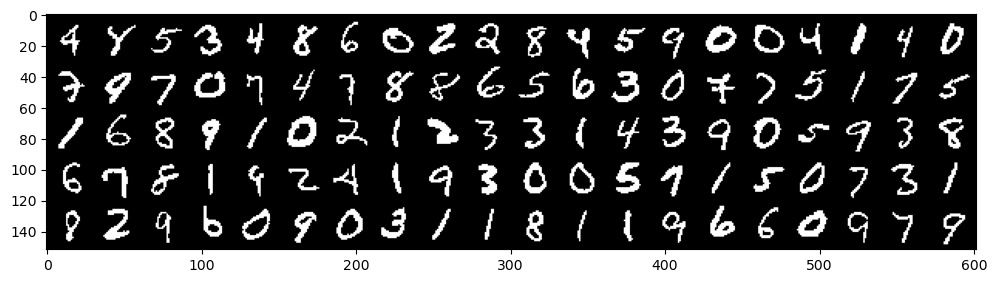

In [3]:
plt.figure(figsize=(12,5))
X_random_batch, y_random_batch = next(iter(train_loader))
plt.imshow(make_grid(X_random_batch, nrow=20).permute(1,2,0));

# TASK 1 (6 points + 2 bonus): Define encoder and decoder networks

We have data $x_i$ and will learn a latent representation $z_i \in \mathbb{R}^{D}$.

To do this we define two different networks, each as an `nn.Module` instance.


* The **Encoder** defines an inference network. It takes a batch of data instances as inputs, and returns a probability distribution $q(z_i | x_i)$ for each $x_i$ in the batch.
* The **Decoder** defines the likelihood in a generative model. It takes a latent value as input, and returns a probability distribution $p(x_i | z_i)$.

## You can use any network architecture you think is appropriate.

Part of your job here is to decide.

* You can get up to 6 points (3 points each) for having an implementation of any non-linear model that runs properly and can be used to fit some sort of VAE. If it doesn't quite work (or if you just implement a linear model, or a poor choice of architecture which leads to bad results) then you will get partial credit.

* You can get 2 additional points if you do something "interesting", by which I specifically mean "more performant". In particular we are looking for architectures which
    - (a) perform better than a feed-forward network, while 
    - (b) having fewer parameters.

In particular: for full *bonus* credit, for a model with `D_latent = 10` you should have fewer than 10,000 parameters each in the encoder and decoder, while still having realistic reconstructions. 


In [4]:
class Encoder(nn.Module):
    
    def __init__(self, D_latent):
        """ 
        Initialize the Encoder `nn.Module`.
        
        This will operate on inputs of shape (batch_size, 1, 28, 28).
        
        INPUTS:
        D_latent: size of latent space (integer)

        """
        super().__init__()
        self.D_latent = D_latent

        self.encode = nn.Sequential(
            # Get basic features: lines, curves, and different angles of
            nn.Conv2d(1, 16, kernel_size=3, stride=2),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            # Look at the average in an area
            nn.MaxPool2d(kernel_size=2),
            # Get more complex features: collections of lines and circles
            nn.Conv2d(16, 32, kernel_size=3, stride=2),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            # Flatten to feature space
            nn.Flatten(),
            # Convert channels to richer latent space
            nn.Linear(32 * 2 * 2, 32),
            # Convert latent space to mean and log standard deviation
            nn.Linear(32, 2 * D_latent)
        )

    def forward(self, X):
        """ Return a distribution q(z | x). 
        
        Remember you can access and variables or `nn.Module` instances defined in the constructor.
        
        INPUT:
        X    : torch.FloatTensor containing zeros and ones; shape = (batch_size, 1, 28, 28)
        
        OUTPUT: a `torch.Distribution` instance, defined on values of shape = (batch_size, D_latent)
        """
        # Encode image as mean and log variance (so unconstrained in model)
        mu, log_sigma = torch.split(self.encode(X), self.D_latent, dim=1)
        sigma = torch.exp(log_sigma)

        assert mu.shape == (X.shape[0], self.D_latent)
        assert mu.shape == sigma.shape
        return dist.Normal(mu, sigma)


In [5]:
from prettytable import PrettyTable

def count_parameters(model):
    table = PrettyTable(["Modules", "Parameters"])
    total_params = 0
    for name, parameter in model.named_parameters():
        # if not parameter.requires_grad:
        #     continue
        params = parameter.numel()
        table.add_row([name, params])
        total_params += params
    print(table)
    print(f"Total Trainable Params: {total_params}")
    return total_params
    
count_parameters(Encoder(10))

+-----------------+------------+
|     Modules     | Parameters |
+-----------------+------------+
| encode.0.weight |    144     |
|  encode.0.bias  |     16     |
| encode.1.weight |     16     |
|  encode.1.bias  |     16     |
| encode.4.weight |    4608    |
|  encode.4.bias  |     32     |
| encode.5.weight |     32     |
|  encode.5.bias  |     32     |
| encode.8.weight |    4096    |
|  encode.8.bias  |     32     |
| encode.9.weight |    640     |
|  encode.9.bias  |     20     |
+-----------------+------------+
Total Trainable Params: 9684


9684

In [6]:
class Decoder(nn.Module):
    
    def __init__(self, D_latent):
        """ 
        Initialize the Decoder `nn.Module`.
        
        This will operate on inputs of shape (batch_size, D_latent).
        
        INPUTS:
        D_latent: size of latent space (integer)

        """
        super().__init__()
        self.D_latent = D_latent
        self.c_start = 6

        # Expand latent space to vector of features
        self.expand = nn.Sequential(
            nn.Linear(self.D_latent, 7 * 7 * self.c_start),
        )

        # USING DECONVOLUTIONS
        # # Input is (8,7,7)
        # self.generate = nn.Sequential(
        #     # (32,13,13)
        #     nn.ConvTranspose2d(self.c_start, 32, kernel_size=3, stride=2, padding=1),
        #     nn.ReLU(),
        #     # (16,27,27)
        #     nn.ConvTranspose2d(32, 16, kernel_size=3, stride=2, padding=0),
        #     nn.ReLU(),
        #     # (1,28,28)
        #     nn.ConvTranspose2d(16, 1, kernel_size=4, stride=1, padding=1),
        #     nn.Sigmoid()
        # )
            
        self.generate = nn.Sequential(
            # Produce a better estimate based on channels and info
            nn.Conv2d(self.c_start, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            # Expand canvas
            nn.UpsamplingBilinear2d((15,15)),
            # Produce low res image
            nn.Conv2d(32, 16, 3),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            # Expand canvas
            nn.UpsamplingBilinear2d((30,30)),
            # Produce final image distribution
            nn.Conv2d(16, 1, 3),
            nn.BatchNorm2d(1),
            # Produce pseudo-probability
            nn.Sigmoid()
        )
        
    def forward(self, Z):
        """ Return a distribution p(x | z) 
                
        INPUT:
        X    : torch.FloatTensor, real-valued, shape = (batch_size, D_latent)
        
        OUTPUT: a `torch.Distribution` instance, defined on values of shape = (batch_size, 1, 28, 28)
        """
        features = self.expand(Z).reshape(-1,self.c_start,7,7)
        X_hat = self.generate(features)

        return dist.Bernoulli(X_hat)


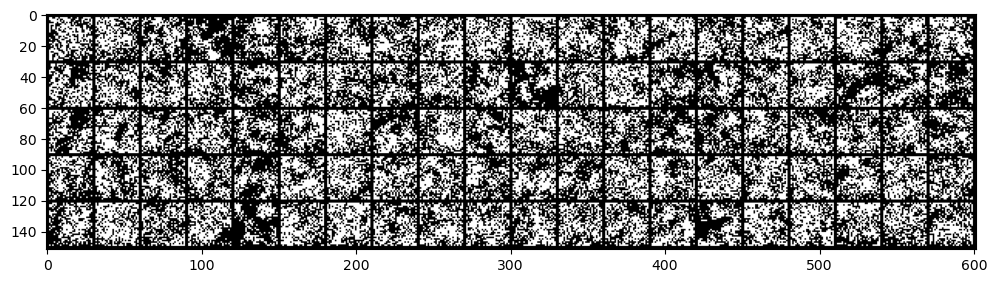

In [7]:
X_random_batch, _ = next(iter(train_loader))
latent_dim = 10
enc = Encoder(latent_dim)
dec = Decoder(latent_dim)

latents = enc(X_random_batch).sample()

plt.figure(figsize=(12,5))
plt.imshow(make_grid(dec(latents).sample(), nrow=20).permute(1,2,0));

In [8]:
count_parameters(Decoder(10))

+-------------------+------------+
|      Modules      | Parameters |
+-------------------+------------+
|  expand.0.weight  |    2940    |
|   expand.0.bias   |    294     |
| generate.0.weight |    1728    |
|  generate.0.bias  |     32     |
| generate.1.weight |     32     |
|  generate.1.bias  |     32     |
| generate.4.weight |    4608    |
|  generate.4.bias  |     16     |
| generate.5.weight |     16     |
|  generate.5.bias  |     16     |
| generate.8.weight |    144     |
|  generate.8.bias  |     1      |
| generate.9.weight |     1      |
|  generate.9.bias  |     1      |
+-------------------+------------+
Total Trainable Params: 9861


9861

# TASK 2 (5 points): Define the objective function

You now need to define the ELBO, which we will maximize when estimating parameters in the encoder and decoder.

## Please use a standard normal prior $N(0, I)$ for the latent space.

I.e., let $$z \sim \mathcal{N}(0, I_D)$$ where $D$ is the dimensionality of the latent space.

The `ELBO_VAE` function should return a **single-sample** Monte Carlo estimate of

$$ELBO(x_i) = \mathbb{E}_{q(z_i | x_i)}\left[ \log \left [ \frac{p(z_i)p(x_i | z_i)}{q(z_i | x_i)} \right ] \right ]$$

where $q(z_i | x_i)$ and $p(x_i | z_i)$ are returned by the `Encoder` and `Decoder` classes you defined above.

Note that I have written this as the **per-datapoint** ELBO. 

For ease of inspecting your code, please have your `ELBO_VAE` function below return a Torch vector, i.e. a tensor of shape `(batch_size,)`, containing the per-datapoint ELBO values.


In [9]:
def ELBO_VAE(enc, dec, X):
    """
    
    INPUT:
    enc : Instance of `Encoder` class, which returns a distribution 
          over Z when called on a batch of inputs X
    dec : Instance of `Decoder` class, which returns a distribution 
          over X when called on a batch of inputs Z
    X   : A batch of datapoints, torch.FloatTensor of shape = (batch_size, 1, 28, 28)
    
    
    OUTPUT: a torch.FloatTensor of shape = (batch_size, ) containing the estimate 
            of the per-datapoint ELBO for every data point in the batch.
    
    """
    # Distributions
    prior = dist.MultivariateNormal(torch.zeros(enc.D_latent),torch.eye(enc.D_latent))
    posterior = enc(X)
    
    # Get a **single sample** of reparameterised q(z|x)
    latent_sample = posterior.rsample()

    # Calculate log probabilities
    log_qz = prior.log_prob(latent_sample)
    log_qz_x = posterior.log_prob(latent_sample)
    log_qx_z = dec(latent_sample).log_prob(X)

    # Assuming that X is i.i.d, the latent variables are i.i.d and the pixels are i.i.d
    return log_qz + log_qx_z.sum((1,2,3)) - log_qz_x.sum(1)


In [10]:
latent_dim = 2
enc = Encoder(latent_dim)
dec = Decoder(latent_dim)
X, _ = next(iter(train_loader))
ELBO_VAE(enc, dec, X)

tensor([-690.3796, -490.9812, -574.8986, -693.4607, -641.9353, -640.7823,
        -643.4191, -678.7832, -604.6049, -522.7391, -629.4015, -634.4341,
        -668.5422, -644.6951, -533.3461, -663.4930, -672.7241, -636.0260,
        -599.8124, -563.8447, -683.6796, -612.4706, -686.6158, -643.4953,
        -526.5441, -575.8386, -663.7722, -640.9249, -628.6209, -672.3411,
        -566.0678, -638.6737, -652.9896, -635.7257, -403.2377, -668.5674,
        -680.6686, -700.7982, -668.9861, -683.3033, -659.7836, -584.3190,
        -669.8568, -609.1317, -598.3604, -484.0880, -623.9869, -510.9792,
        -655.2244, -673.4570, -523.6179, -663.4174, -577.5551, -604.9222,
        -586.8118, -663.4139, -586.7706, -702.9487, -666.4579, -529.4708,
        -581.4910, -599.7672, -651.4909, -640.1154, -683.2273, -611.6056,
        -636.6793, -676.8452, -639.0000, -594.6260, -658.3307, -576.0056,
        -691.8273, -663.7752, -683.1463, -627.8961, -674.2650, -658.7144,
        -625.3247, -591.5120, -624.112

# Train the VAE and look at the results

The following code to train and run the VAE has already been written for you. 

You can use it to evaluate whether or not your model is working as you might expect, and for experimenting with its behavior as you change different parameters.

You should't have to change the two following cells. Feel free to modify them (e.g. for adding debugging information), but be aware that I will test your implementations with substantially similar code. So, your code should be runnable by calling these cells as-is.

In [11]:
# Try modifying this and seeing how it affects performance!
D_latent = 2

enc = Encoder(D_latent)
dec = Decoder(D_latent)

opt_vae = torch.optim.Adam(itertools.chain(enc.parameters(), dec.parameters()))

In [12]:
def run_training(N_epochs, enc, dec):
    """ Outer loop for training the VAE 
    
        Calls your `ELBO_VAE` function!
    """
    for epoch in range(N_epochs):
        train_loss = 0.0
        for (X, _) in train_loader:
            opt_vae.zero_grad()
            
            # Call you ELBO implementation
            elbos = ELBO_VAE(enc, dec, X)
            
            # Please don't break the following assertion (check your return shape!)
            batch_size = X.shape[0]
            assert elbos.shape == (batch_size,)
            
            # The loss is the sum of the negative per-datapoint ELBO
            loss = -elbos.sum()
            loss.backward()
            opt_vae.step()
            train_loss += loss.item() * X.shape[0] / len(mnist_dataset)
        print("Epoch %d, train loss = %0.4f" % (epoch, train_loss));

In [13]:
# ignore this cell (placeholder)


In [14]:
N_epochs = 15 # Note that you may want to run more epochs!
run_training(N_epochs, enc, dec)

Epoch 0, train loss = 38706.8612
Epoch 1, train loss = 27111.6278
Epoch 2, train loss = 21647.7080
Epoch 3, train loss = 18516.1871
Epoch 4, train loss = 16561.4778
Epoch 5, train loss = 15303.2394
Epoch 6, train loss = 14462.4218
Epoch 7, train loss = 13896.5812
Epoch 8, train loss = 13507.4421
Epoch 9, train loss = 13215.8269
Epoch 10, train loss = 13015.4787
Epoch 11, train loss = 12864.3217
Epoch 12, train loss = 12745.2695
Epoch 13, train loss = 12657.7717
Epoch 14, train loss = 12591.6960


## Do reconstructions look like the input?

Reconstruction accuracy: 0.91


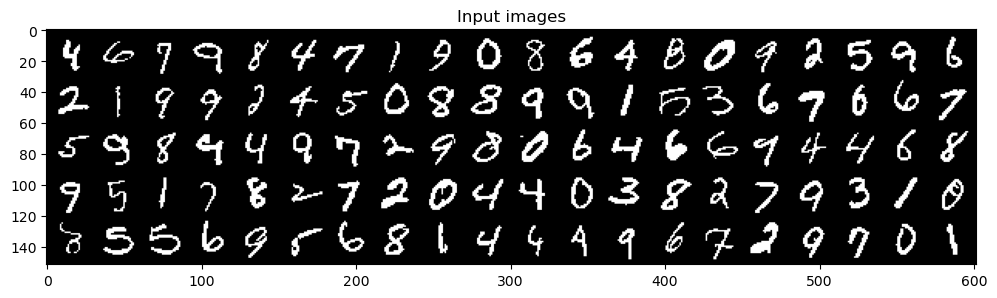

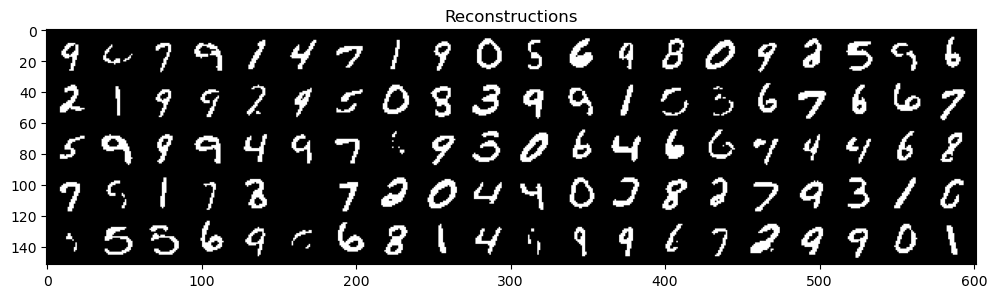

In [15]:
plt.figure(figsize=(12, 4))
plt.imshow(make_grid(X_random_batch, nrow=20).permute(1,2,0))
plt.title("Input images")
plt.figure(figsize=(12, 4))
plt.title("Reconstructions")
with torch.no_grad():
    plt.imshow(make_grid(dec(enc(X_random_batch).sample()).mean.round(), nrow=20).permute(1,2,0))
    
print("Reconstruction accuracy: %0.2f" % (X_random_batch == dec(enc(X_random_batch).sample()).sample()).float().mean().item())

## Do randomly generated samples look coherent?

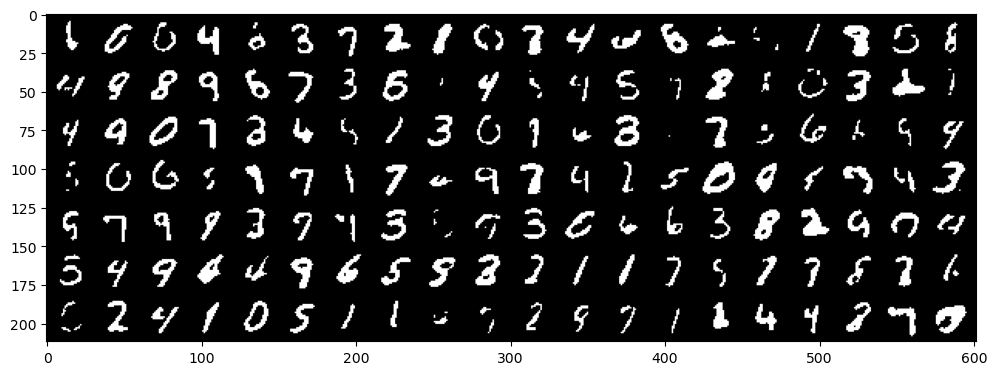

In [16]:
plt.figure(figsize=(12,5))
with torch.no_grad():
    plt.imshow(make_grid(dec(dist.Normal(0, 1).sample((140, D_latent))).mean.round(), nrow=20).permute(1,2,0), vmin=0, vmax=1)

## What does the latent space look like?

Note that this will only give sensible plots for very low-dimensional latent spaces. It works best if the latent space is actually 2d. Otherwise, it will plot a 2d cross-section that may or may not be informative.

/usr/lib/python3.12/site-packages/torch/functional.py:534: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /build/python-pytorch/src/pytorch/aten/src/ATen/native/TensorShape.cpp:3595.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


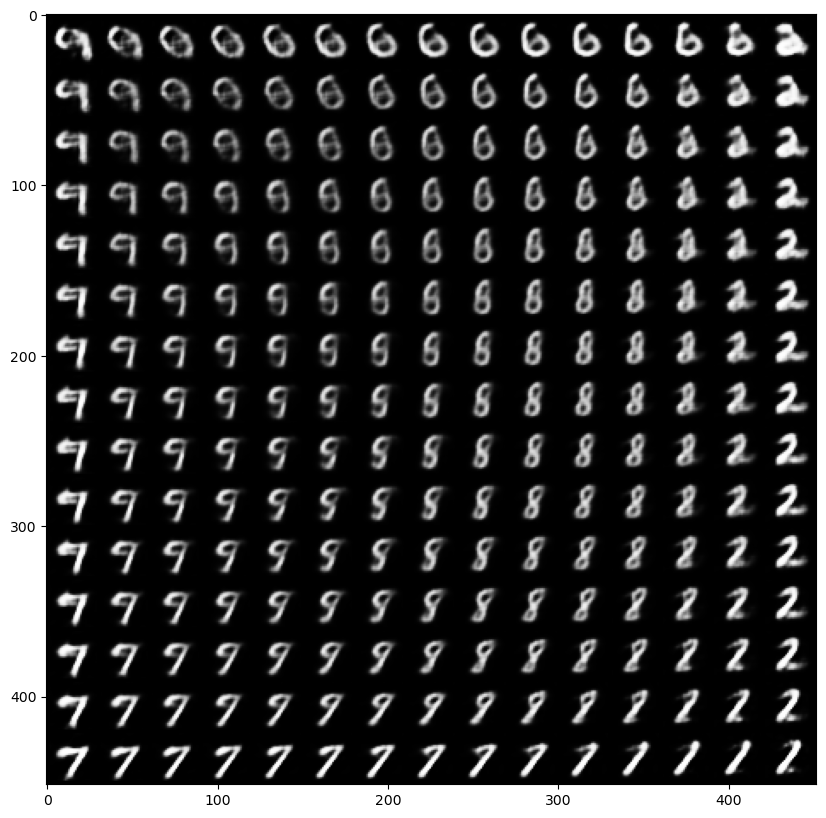

In [17]:
def plot_2d_latent(encoder, decoder):
    """ If this is a 2d latent space, it plots the latent space
        If the latent space is larger than 2d, then it plots a 2d cross-section """
    W = torch.linalg.svd(encoder(X_random_batch).mean).Vh[:2]
    points = dist.Normal(0, 1).icdf(torch.linspace(0.01, 0.99, 15))
    XX, YY = torch.meshgrid(points, points)
    XXYY = torch.stack((XX, YY)).reshape(2, -1).T
    with torch.no_grad():
        out = dec(XXYY @ W).mean
    plt.imshow(make_grid(out, nrow=len(points)).permute(1,2,0))

plt.figure(figsize=(10, 10))
out = plot_2d_latent(enc, dec)

In [18]:
# feel free to try out other things here -- for example, interpolation in the latent space between two digits

In [19]:
X_random_batch, y_random_batch = next(iter(train_loader))
print(y_random_batch)

tensor([1, 6, 7, 6, 9, 5, 2, 3, 1, 4, 4, 3, 3, 5, 0, 0, 3, 4, 9, 3, 7, 1, 6, 0,
        0, 6, 2, 8, 1, 5, 4, 8, 2, 6, 2, 3, 3, 5, 1, 0, 3, 5, 7, 8, 2, 0, 9, 3,
        4, 8, 6, 7, 9, 5, 7, 9, 8, 3, 9, 0, 0, 6, 0, 2, 2, 5, 9, 4, 6, 2, 3, 0,
        7, 8, 1, 9, 6, 1, 8, 8, 8, 5, 0, 9, 7, 3, 0, 6, 3, 0, 4, 9, 5, 0, 8, 1,
        4, 0, 1, 6])


In [20]:
class LatentClassifier(nn.Module):
    
    def __init__(self, D_latent, num_classes):
        super().__init__()
        self.D_latent = D_latent
        self.classify = nn.Sequential(
            nn.Linear(D_latent, num_classes),
            nn.Softmax()
        )

    def forward(self, X):
        return self.classify(X)


In [21]:
cls = LatentClassifier(D_latent, 10)

opt_cls = torch.optim.Adam(cls.parameters())
criterion = nn.CrossEntropyLoss()

def train_classifier(N_epochs, enc, cls):
    """ Outer loop for training the VAE 
    
        Calls your `ELBO_VAE` function!
    """
    # Freeze the encoder to prevent it being corrupted
    enc.train(False)

    for epoch in range(N_epochs):
        train_loss = 0.0
        for (X, y) in train_loader:
            opt_cls.zero_grad()
            
            output = cls(enc(X).sample())
            label = nn.functional.one_hot(y, num_classes=10)
            
            # The loss is the sum of the negative per-datapoint ELBO
            loss = criterion(output, y)
            loss.backward()
            opt_cls.step()
            train_loss += loss.item() / len(train_loader)
        print("Epoch %d, train loss = %0.4f" % (epoch, train_loss));

    # Return trainability to prevent unexpected behaviour
    enc.train(True)

In [22]:
train_classifier(20, enc, cls)

/usr/lib/python3.12/site-packages/torch/nn/modules/module.py:1736: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)


Epoch 0, train loss = 2.2366
Epoch 1, train loss = 2.1289
Epoch 2, train loss = 2.0617
Epoch 3, train loss = 2.0308
Epoch 4, train loss = 2.0066
Epoch 5, train loss = 1.9860
Epoch 6, train loss = 1.9693
Epoch 7, train loss = 1.9561
Epoch 8, train loss = 1.9453
Epoch 9, train loss = 1.9364
Epoch 10, train loss = 1.9288
Epoch 11, train loss = 1.9218
Epoch 12, train loss = 1.9150
Epoch 13, train loss = 1.9082
Epoch 14, train loss = 1.9017
Epoch 15, train loss = 1.8957
Epoch 16, train loss = 1.8902
Epoch 17, train loss = 1.8854
Epoch 18, train loss = 1.8811
Epoch 19, train loss = 1.8769


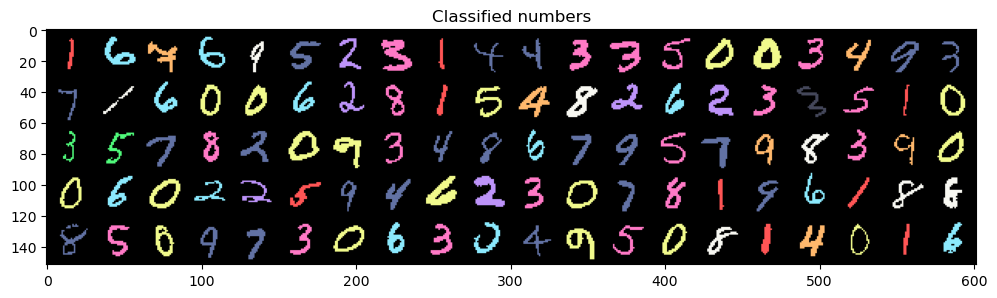

In [23]:
def num_to_colour(preds):
    nums = torch.argmax(preds, dim=1)
    
    black = torch.tensor([[0, 0, 0]]).expand(nums.size(0),-1)
    c_zero = torch.tensor([[241,250,140]]).expand(nums.size(0),-1)
    c_one = torch.tensor([[255,85,85]]).expand(nums.size(0),-1)
    c_two = torch.tensor([[189,147,249]]).expand(nums.size(0),-1)
    c_three = torch.tensor([[255,121,198]]).expand(nums.size(0),-1)
    c_four = torch.tensor([[255,184,108]]).expand(nums.size(0),-1)
    c_five = torch.tensor([[80,250,123]]).expand(nums.size(0),-1)
    c_six = torch.tensor([[139,233,253]]).expand(nums.size(0),-1)
    c_seven = torch.tensor([[98,114,164]]).expand(nums.size(0),-1)
    c_eight = torch.tensor([[248,248,242]]).expand(nums.size(0),-1)
    c_nine = torch.tensor([[68,71,90]]).expand(nums.size(0),-1)

    colour_nums = nums.unsqueeze(-1).expand(-1, 3)
    cmap = torch.where(colour_nums == 0, c_zero, black)
    cmap = torch.where(colour_nums == 1, c_one, cmap)
    cmap = torch.where(colour_nums == 2, c_two, cmap)
    cmap = torch.where(colour_nums == 3, c_three, cmap)
    cmap = torch.where(colour_nums == 4, c_four, cmap)
    cmap = torch.where(colour_nums == 5, c_five, cmap)
    cmap = torch.where(colour_nums == 6, c_six, cmap)
    cmap = torch.where(colour_nums == 7, c_seven, cmap)
    cmap = torch.where(colour_nums == 8, c_eight, cmap)
    cmap = torch.where(colour_nums == 9, c_nine, cmap)

    return cmap.unsqueeze(-1).unsqueeze(-1)

plt.figure(figsize=(12, 4))
plt.title("Classified numbers")
with torch.no_grad():
    sample = enc(X_random_batch).sample()
    rgb_img = X_random_batch.round().expand(-1,3,-1,-1)
    cmap = num_to_colour(cls(sample)).expand(-1,-1,28,28)
    #print(rgb_img.size(), cmap.size())
    rgb_img = (rgb_img * cmap) / 255
    plt.imshow(make_grid(rgb_img, nrow=20).permute(1,2,0))
    #print(torch.argmax(cls(sample), dim=1).reshape(-1,20))

In [38]:
def plot_2d_latent_with_class(encoder, decoder, classifier):
    W = torch.linalg.svd(encoder(X_random_batch).mean).Vh[:2]
    points = dist.Normal(0, 1).icdf(torch.linspace(0.01, 0.99, 20))
    XX, YY = torch.meshgrid(points, points)
    XXYY = torch.stack((XX, YY)).reshape(2, -1).T
    with torch.no_grad():
        latent = XXYY @ W
        out = decoder(latent).mean.expand(-1,3,-1,-1)
        num = classifier(latent)
        cmap = num_to_colour(cls(latent)).expand(-1,-1,28,28)
        out = (out * cmap) / 255
    plt.imshow(make_grid(out, nrow=len(points)).permute(1,2,0))


plt.figure(figsize=(10, 10))
plt.tick_params(
    axis='x',
    which='both',
    bottom=False,
    top=False,
    labelbottom=False
)
plt.tick_params(
    axis='y',
    which='both',
    left=False,
    right=False,
    labelleft=False
)
plt.legend(np.arange(10), ['0','1','2','3','4','5','6','7','8','9'], loc="best")
out = plot_2d_latent_with_class(enc, dec, cls)

/tmp/ipykernel_229077/2558228264.py:30: UserWarning: Legend does not support handles for int64 instances.
A proxy artist may be used instead.
See: https://matplotlib.org/stable/users/explain/axes/legend_guide.html#controlling-the-legend-entries
  plt.legend(np.arange(10), ['0','1','2','3','4','5','6','7','8','9'], loc="best")


In [25]:
%matplotlib qt

In [34]:
from matplotlib.widgets import Slider

def latent_to_img(latent_point, decoder):
    with torch.no_grad():
        out = decoder(latent_point).mean.squeeze(0).expand(3,-1,-1)
    return out.permute(1,2,0)

init_x = 0
init_y = 0

fig, ax = plt.subplots()
img = ax.imshow(latent_to_img(torch.tensor([[init_x, init_y]], dtype=torch.float), dec))

fig.subplots_adjust(bottom=0.25)

ax_x = fig.add_axes([0.33, 0.15, 0.36, 0.03])
x_slider = Slider(
    ax=ax_x,
    label='latent x',
    valmin=-2.5,
    valmax=2.5,
    valinit=init_x
)

ax_y = fig.add_axes([0.25, 0.25, 0.0225, 0.63])
y_slider = Slider(
    ax=ax_y,
    label='latent y',
    valmin=-2.5,
    valmax=2.5,
    valinit=init_y,
    orientation="vertical"
)

def update(val):
    new_img = latent_to_img(torch.tensor([[x_slider.val, y_slider.val]], dtype=torch.float), dec)
    img.set_data(new_img)
    fig.canvas.draw_idle()

x_slider.on_changed(update)
y_slider.on_changed(update)

ax.tick_params(
    axis='x',
    which='both',
    bottom=False,
    top=False,
    labelbottom=False
)
ax.tick_params(
    axis='y',
    which='both',
    left=False,
    right=False,
    labelleft=False
)

plt.show()

In [27]:
##### grading


In [28]:
# grading


In [29]:
# grading


In [30]:
# grading


In [31]:
# grading


In [32]:
# grading


In [33]:
# grading
